# Data Exploration

In this notebook, we explore the listening behavior of high-activity Last.fm users in the United States by combining Last.fm data with Spotify audio features. The goal of this analysis is to understand user-level listening patterns and investigate how Spotify track characteristics relate to a user's overall listening diversity.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading User-Level Feature Data

We begin by loading the user-level dataset created in `data_collection.ipynb`. This dataset contains Spotify-derived audio features averaged across each user's top tracks. We also load the original Last.fm top tracks to compute each user’s listening diversity.




In [11]:
user_features = pd.read_csv("data/user_features.csv", index_col="user_id")

users = pd.read_csv("data/users.csv")

top_tracks = pd.read_csv("data/user_top_tracks.csv")

### Computing Artist Diversity

Artist (or track) diversity is defined as the number of unique tracks a user has in their top-track list. Using `groupby` and `nunique`, we compute this quantity for each user.

In [12]:
top_tracks["track_name"] = top_tracks["track_name"].str.lower().str.strip()

artist_diversity = top_tracks.groupby("user_id")["track_name"].nunique()

user_features["artist_diversity"] = artist_diversity

### Summary Statistics

We use `.describe()` to summarize each quantitative variable. These statistics help us understand the mean, median, standard deviation, min, and max of Spotify audio features across users.


In [4]:
user_features.head()
user_features.describe()
user_features.shape


(14063, 21)

### Distributions of Spotify Audio Features

We visualize the distribution of several user-level Spotify features using histograms. 

- **Energy** and **Danceability** show approximately normal distributions.
- **Acousticness** and **Instrumentalness** are heavily right-skewed, meaning most users listen to tracks with low acousticness/instrumentalness.
- **Popularity** is centered around 40–60, indicating that users tend to listen to moderately popular tracks.

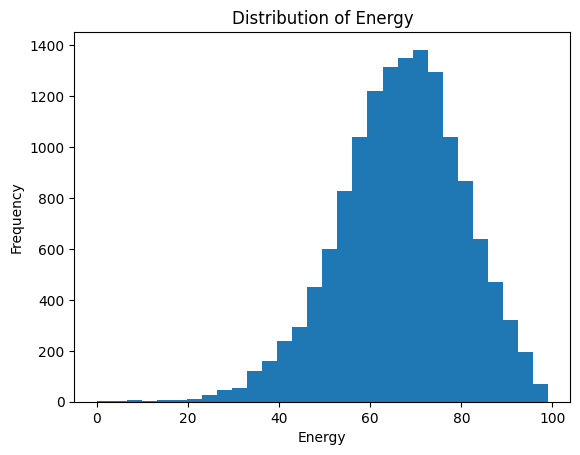

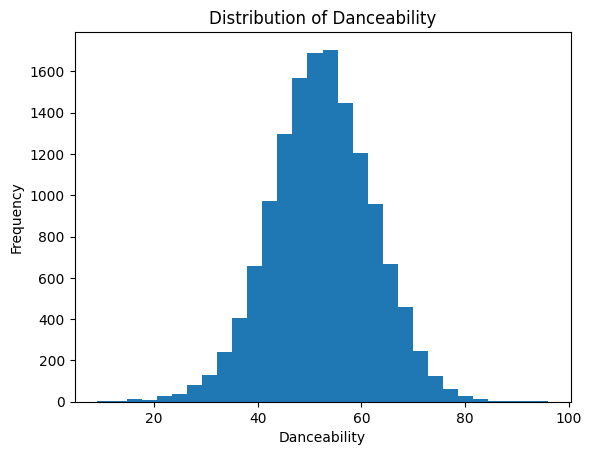

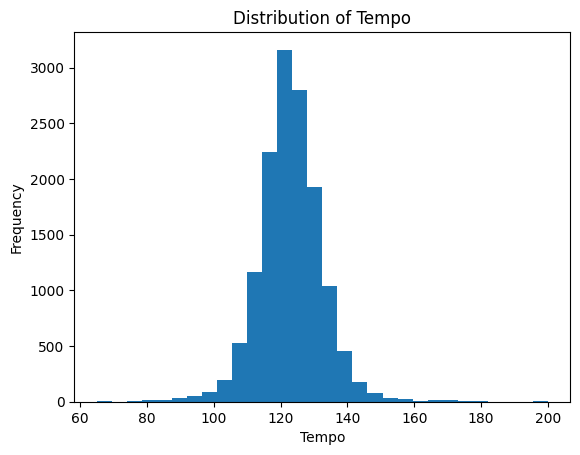

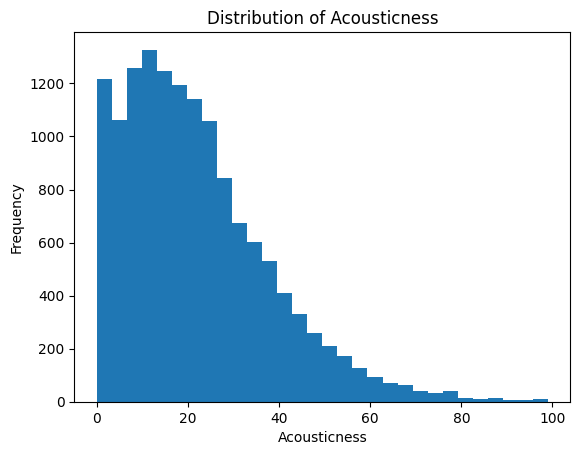

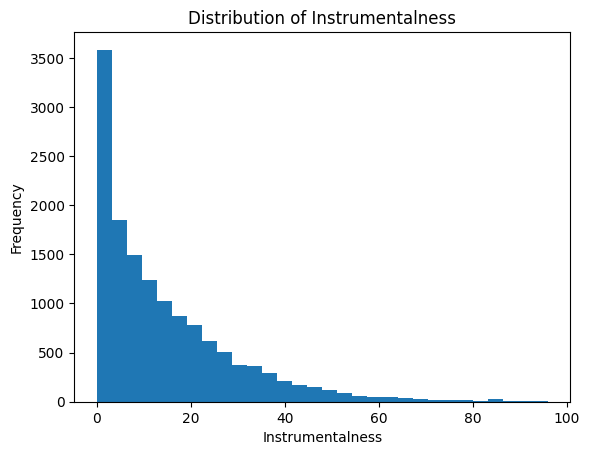

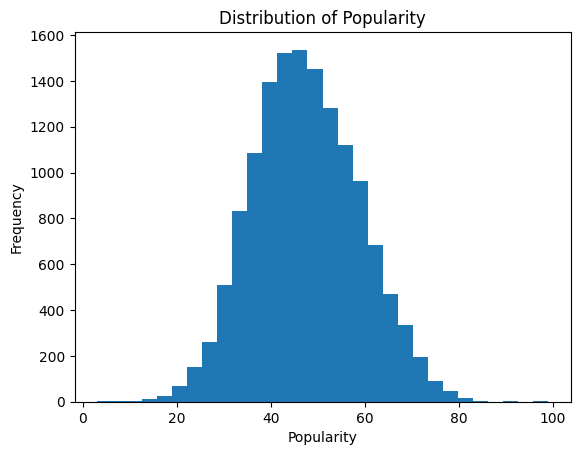

In [5]:
features_to_plot = ["Energy", "Danceability", "Tempo", "Acousticness",
                    "Instrumentalness", "Popularity"]

for f in features_to_plot:
    user_features[f].plot.hist(bins=30)
    plt.title(f"Distribution of {f}")
    plt.xlabel(f)
    plt.ylabel("Frequency")
    plt.show()


### Correlation Between Spotify Features

We compute and visualize the correlation matrix of the user-level features. 

- **Energy** and **Danceability** are positively correlated, meaning users who listen to energetic music also tend to listen to danceable music.
- **Acousticness** is negatively correlated with Energy and Danceability.
- **Similarity Score** features are strongly correlated with each other, as expected.

This heatmap helps reveal underlying structure in the user listening data.


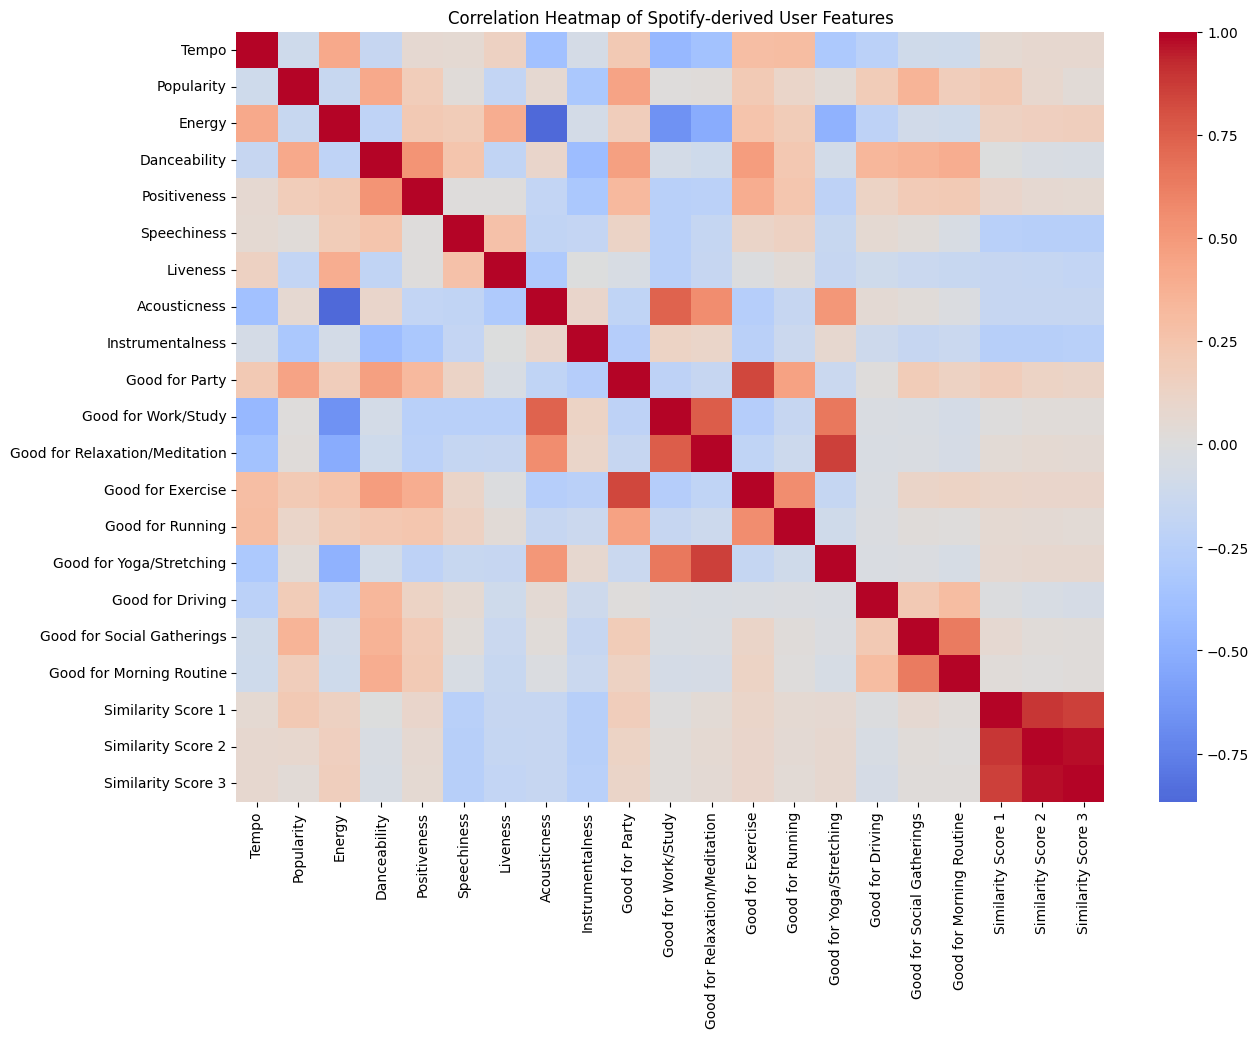

In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(user_features.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Spotify-derived User Features")
plt.show()


### Distribution of Artist Diversity

We plot the distribution of `artist_diversity`, which measures how many unique tracks appear in each user’s top-50 tracks.

Most users have very high diversity because the Last.fm dataset provides each user's *top 50* tracks, and many users have 50 distinct tracks. A small number of users repeat tracks within their top list, resulting in lower diversity.

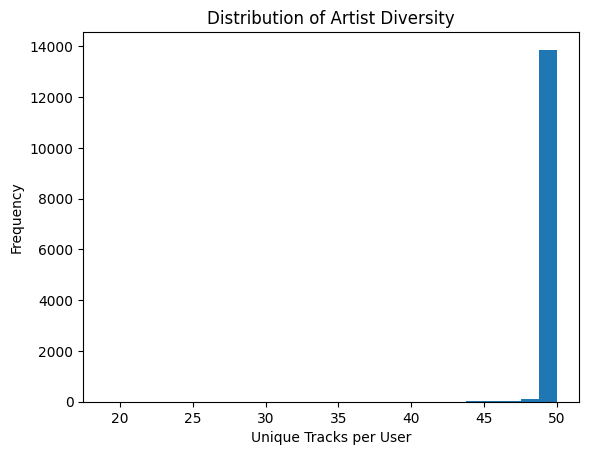

In [10]:
user_features["artist_diversity"].plot.hist(bins=25)
plt.title("Distribution of Artist Diversity")
plt.xlabel("Unique Tracks per User")
plt.show()


### High vs Low Diversity Groups

To compare groups of users, we convert `artist_diversity` into a binary variable using the median as the cutoff:
- Users above the median are labeled **1** (high diversity)
- Users at or below the median are labeled **0** (low diversity)

In [13]:
threshold = user_features["artist_diversity"].median()
user_features["high_diversity"] = (user_features["artist_diversity"] > threshold).astype(int)


### Relationship Between Artist Diversity and Audio Features

We use scatterplots to explore the relationship between `artist_diversity` and Spotify audio features such as Energy.

The trend shows that most users cluster around high diversity, but within that group, there is variation in the Energy levels of their listened tracks.


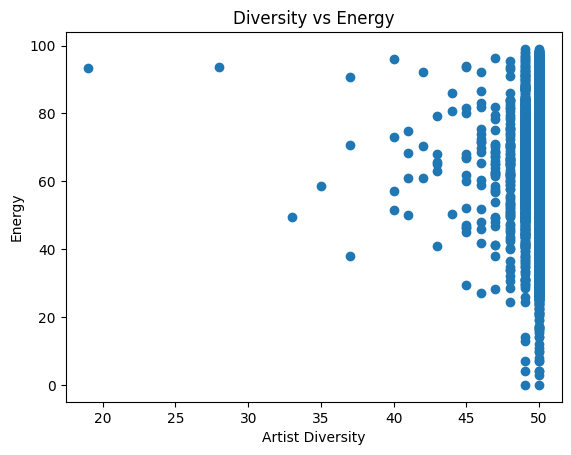

In [14]:
plt.scatter(user_features["artist_diversity"], user_features["Energy"])
plt.xlabel("Artist Diversity")
plt.ylabel("Energy")
plt.title("Diversity vs Energy")
plt.show()


### Comparing High vs Low Diversity Users

Using boxplots, we compare how Spotify audio features differ between high-diversity and low-diversity users. 

- High-diversity users may have slightly higher average Danceability.
- Low-diversity users may have more variation in certain features.

These comparisons help us understand whether listening diversity is associated with distinct musical preferences.


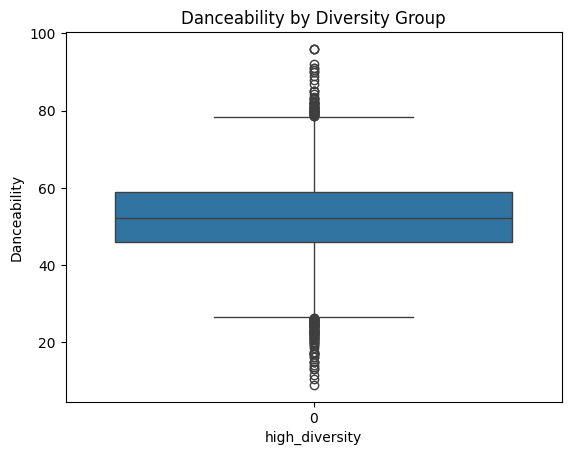

In [15]:
sns.boxplot(x="high_diversity", y="Danceability", data=user_features)
plt.title("Danceability by Diversity Group")
plt.show()
